# Joinville Meteo Dashboard — the pipeline, end to end

**A reproducible, plain-language + scientifically-documented walkthrough of how raw station and
model data become the public dashboard.**

Author: Jess (LaCiA · PPGEC · UDESC–CCT, Joinville), with Claude (Cowork).

---

### What this notebook is
A single place that explains **every step** from raw instrument files to the published web pages —
*what* each step does, *why* it is done that way (with references), and the *exact code* that does it.
It is written so that **a non-specialist can follow the logic** and a **scientist can reproduce every
number**. Nothing here is invented: every value traces to a measurement, a peer-reviewed method, or
plain mathematics; known limitations are stated, not hidden.

### The three R's (why it's built this way)
- **Repeatable** — the same input always gives the same output (deterministic scripts, fixed rules).
- **Replicable** — someone else, with the same data, gets the same result (all rules are explicit and
  parameterised at the top of each script).
- **Reproducible** — the whole site rebuilds itself from raw files with no manual steps (GitHub
  Actions run the scripts; GitHub Pages serves the result).

### How to run it
Open this notebook at the **repository root** (the folder that contains `scripts/`, `site/`, `data/`).
The cells below read the data already produced by the pipeline and re-derive the key diagnostics, so
you can *see* the evidence behind each decision. Cells that need the network (WRF download, NOAA ONI)
or the heavy raw masters are marked and guarded — they won't crash if those aren't present.

In [1]:
# --- setup: locate the repo root and load helpers ------------------------------------------------
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand/"scripts").is_dir() and (cand/"site").is_dir():
            return cand
    return p

ROOT = find_root()
DATA, SITE = ROOT/"data", ROOT/"site"/"data"
sys.path.insert(0, str(ROOT/"scripts"))
print("repo root :", ROOT)
print("has raw masters (data/hourly):", (DATA/"hourly").is_dir())
print("has site outputs (site/data) :", SITE.is_dir())
def load_json(p):
    p = Path(p)
    return json.loads(p.read_text(encoding="utf-8")) if p.exists() else None

repo root : /root/joinville-meteo-dashboard
has raw masters (data/hourly): True
has site outputs (site/data) : True


## 1 · Architecture — how data flows

The dashboard is a **static site**: there is no server doing calculations when someone opens a page.
Instead, Python scripts turn raw data into a handful of small, clean files (`site/data/*.json|csv|geojson`),
and each web page is plain HTML+JavaScript that just *draws* those files. This is why it is free to host,
always online, and rebuilds itself automatically.

```
 RAW INPUTS                        PROCESSING (scripts/)                 SMALL FILES (site/data/)        PAGES (site/*.html)
 ─────────                         ─────────────────────                 ───────────────────────        ──────────────────
 Campbell TOA5 loggers  ┐          consolidate.py / toa5.py     ┐        snapshot.json                  index.html   (Agora)
 (*_HR, *_DIARIA, .dat) ├─ingest─► build_hourly_daily.py ──QC──►│        city_history.json              cidade*.html (Cidade)
 Defesa Civil gauges    ┘          update_datasets.py (weekly)   │        station_history.json           estacao.html (Estação)
                                   rain_qc.py  (rainfall QC)     ├─build─►disasters.json                risco.html   (Risco)
 IBGE shapefiles ───────────────►  build_data.py                 │        river.json + river/<code>.json  rio.html     (Chuva–Rio)
 NOAA/CPC ONI table ────────────►  build_enso.py                 │        enso.json                      (bands on rio.html)
 CPTEC/INPE WRF (7 km) ─────────►  fetch_wrf.py→build_wrf_basins │        wrf_*.{json,csv,geojson,png}    previsao.html(Previsão)
                                   archive_wrf_grid.py           ┘        wrf_grid_archive.csv (history)  sobre.html   (Sobre/method)
                                                                          │
                          GitHub Actions run the scripts on a schedule ───┘  ► git commit ► GitHub Pages serves site/
```

Every arrow is a script you can read; every box on the right is a file you can download.

## 2 · Data sources & provenance

| Source | What it gives | Cadence | Notes / reference |
|---|---|---|---|
| **SEPROT / Defesa Civil** automatic weather + hydro stations (Campbell TOA5) | temperature, humidity, wind, rain, solar, river stage | 5-min / hourly / daily | primary network; loggers record **local standard time** |
| **Defesa Civil rain-gauge (pluviômetro) network** | daily rainfall at many points | daily / 10-min | used for the spatial **city rainfall** |
| **IBGE** | municipal limit, neighbourhoods (bairros), state outlines | static | boundaries for maps & area-weighting |
| **ANA / local SIG** hydrographic base | 7 hydrological basins of Joinville | static | basin polygons |
| **NOAA / CPC** Oceanic Niño Index (ONI) | El Niño / La Niña state | monthly | ENSO bands (ref. CPC ONI) |
| **CPTEC / INPE** WRF, domain AMS **7 km** | rain, 2-m temperature, 10-m wind forecast | 00Z / 12Z daily | numerical forecast (Previsão page) |

Reference annual rainfall for Joinville ≈ **2,130 mm** (42-gauge mean since 1950; De Mello, 2020).

## 3 · Stage A — Ingestion & consolidation

Each Campbell logger writes tables in its own format with fault codes (`-100`, `NAN`, `-6999`, …) and
the occasional physically-impossible value. `scripts/toa5.py` maps every logger's field names to one
standard schema, converts wind km/h→m/s, strips those missing-value codes, and applies **hard
physical-range limits**; `build_hourly_daily.py` (baseline) and `update_datasets.py` (weekly) merge
all sources into **one hourly and one daily master per station**, de-duplicated by timestamp.
*(The step-by-step of this stage — TOA5 readers, station manifest, coverage inventory — is in the
companion notebook `joinville_meteo_consolidation.ipynb`.)*

The cell below shows the clean schema of a consolidated master.

In [2]:
# One consolidated hourly master (already ingested + range-QC'd). Local time; standard columns.
p = DATA/"hourly"/"flotflux.csv"
if p.exists():
    df = pd.read_csv(p, parse_dates=["date"])
    print("station 'flotflux' (Cachoeira Área Central) — hourly master")
    print("rows:", len(df), "| period:", df.date.min().date(), "→", df.date.max().date())
    print("columns:", list(df.columns))
    display(df.head(3))
else:
    print("(raw masters not in this bundle — run in the full repo to see them)")

station 'flotflux' (Cachoeira Área Central) — hourly master
rows: 116622 | period: 2011-01-18 → 2026-07-15
columns: ['date', 'level', 'level_max', 'level_min', 'temp', 'umid', 'ws', 'wd', 'solar', 'gust', 'prec', 'dewpoint', 'heat_index', 'wind_chill', 'gust_dir']


,date,level,level_max,level_min,temp,umid,ws,wd,solar,gust,prec,dewpoint,heat_index,wind_chill,gust_dir
0,2011-01-18 02:00:00,0.762114,0.762798,0.759595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-18 03:00:00,0.762456,0.762632,0.758598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-01-18 04:00:00,0.776908,0.777240,0.762449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4 · Stage B — Quality control (the scientific core)

Range checks alone do **not** catch faults that fall *inside* the physical range. Three targeted,
transparent QC layers were added. All of them **flag, they do not silently delete**: removed points
become **missing (NaN)**, never 0 (a 0 would bias totals *down*), and every removed point is written
to an audit file. This follows the WMO guidance (WMO-No. 8) to range/consistency-check and *flag*
suspect data rather than erase it.

### 4.1 Rainfall — the inch-based logger error code

The tipping buckets are **inch-based** (tip resolution 0.254 mm = 0.01 in). Their fault/overflow code
appears as an **exact inch value** in the rain field. The signature is unmistakable: **254.0 mm =
10.00 in** occurs over a thousand times, and both the 99.9ᵗʰ and 99.99ᵗʰ percentiles land *exactly* on
254.0 — that is a sentinel, not weather. The rule (`scripts/rain_qc.py`):

- `inch_code` — remove exactly **254.0** (10 in) and **228.6** (9 in). *Keep* 25.4 / 50.8 mm (1–2 in):
  those are plausible real hourly totals.
- `ceiling` — remove > **150 mm h⁻¹** (or > **350 mm day⁻¹**). The data show a clean *empty gap*
  between credible storm values (≤ ~115 mm h⁻¹) and an instrument shelf (≥ ~229 mm h⁻¹).
- `gap_dump` — remove a large value (≥ 40 mm) reported in the hour right after a > 2 h data gap
  (multi-hour rain dumped into one bucket).

**A note on running order.** The pipeline's masters are stored *already QC'd*, and the durable proof
of what was found and removed is the **audit report** `data/processed/rain_qc_flags.csv`. So we read
that first (it always shows the evidence), then confirm the current masters are clean.

In [3]:
# (1) The audit trail — the durable record of every removed rain point (station, date, raw value, why).
rep = DATA/"processed"/"rain_qc_flags.csv"
if rep.exists():
    r = pd.read_csv(rep)
    print(f"points flagged & removed across the network : {len(r):,}")
    print(f"  exactly 254.0 mm (=10 in), the sentinel   : {(r.raw_prec==254.0).sum():,}")
    print(f"  exactly 228.6 mm (= 9 in)                 : {(r.raw_prec==228.6).sum():,}")
    print("\nby resolution and reason:")
    print(r.groupby(['kind','reason']).size().rename('n').to_frame().to_string())
    display(r.head(4))
else:
    print("(no audit report here — run rain_qc.py in the full repo to generate it)")

points flagged & removed across the network : 1,236
  exactly 254.0 mm (=10 in), the sentinel   : 1,169
  exactly 228.6 mm (= 9 in)                 : 8

by resolution and reason:
                     n
kind   reason         
daily  ceiling       5
       inch_code    79
hourly ceiling      51
       gap_dump      3
       inch_code  1098


,station,kind,date,raw_prec,reason
0,aguasdejoi,hourly,2017-11-30 13:00:00,488.5,ceiling
1,aguasdejoi,hourly,2022-01-10 09:00:00,254.0,inch_code
2,aguasdejoi,hourly,2022-01-28 14:00:00,254.0,inch_code
3,aguasdejoi,hourly,2022-02-04 01:00:00,254.0,inch_code


In [4]:
# (2) Confirm the current masters are physical: the sentinel is gone and the tail is sensible.
import glob
allx = []
for p in sorted(glob.glob(str(DATA/"hourly"/"*.csv"))):
    d = pd.read_csv(p)
    if "prec" in d.columns:
        allx.append(pd.to_numeric(d["prec"], errors="coerce").dropna().values)
if allx:
    x = np.concatenate(allx)
    print(f"hourly rain points now in masters   : {len(x):,}")
    print(f"still exactly 254.0 mm              : {(x==254.0).sum()}  (0 = cleaned)")
    print(f"99.9th percentile (now)            : {np.percentile(x,99.9):6.2f} mm  (physical; was exactly 254.0 pre-QC)")
    print(f"global max hourly rate (now)       : {x.max():6.2f} mm/h  (physical)")
else:
    print("(raw masters not in this bundle — the audit report above is the record)")

hourly rain points now in masters   : 824,529
still exactly 254.0 mm              : 0  (0 = cleaned)
99.9th percentile (now)            :  18.31 mm  (physical; was exactly 254.0 pre-QC)
global max hourly rate (now)       : 115.40 mm/h  (physical)


In [5]:
# rain_qc is reusable: show the rule on a tiny worked example (no data needed).
import rain_qc
dates = pd.date_range("2026-01-01", periods=6, freq="h").tolist()
# note the 5th point follows a 4-hour gap:
dates[5] = dates[4] + pd.Timedelta(hours=4)
prec  = [0.2, 254.0, 3.0, 900.0, 0.0, 60.0]   # real, inch-code, real, gross spike, real, catch-up dump
flags = rain_qc.flag_rain(dates, prec, kind="hourly")
display(pd.DataFrame({"date":dates, "prec":prec, "flag":flags.values}))
print("→ inch_code=254.0 removed, ceiling removes 900, gap_dump removes the 60 after the 4-h gap; reals kept.")

,date,prec,flag
0,2026-01-01 00:00:00,0.2,NaN
1,2026-01-01 01:00:00,254.0,inch_code
2,2026-01-01 02:00:00,3.0,NaN
3,2026-01-01 03:00:00,900.0,ceiling
4,2026-01-01 04:00:00,0.0,NaN
5,2026-01-01 08:00:00,60.0,gap_dump


→ inch_code=254.0 removed, ceiling removes 900, gap_dump removes the 60 after the 4-h gap; reals kept.


### 4.2 Wind direction — stuck / absent vane, and calm

A wind vane cannot report a direction when the air is nearly still, and a broken vane can sit at one
value forever. On the network, two stations report direction **exactly 0° (North)** for ~41 % of hours
*with wind blowing* — that is a stuck/absent vane, not real North. So for the **wind rose**
(`build_site_data.py`):

- **calm** winds (speed < 0.5 m s⁻¹) get no direction and are reported as a **calm %**;
- **broken-vane stations** — > 25 % of *windy* hours pinned to exactly 0° — are **excluded**.

The rose then shows the physically-expected **East quadrant** (Atlantic sea breeze) instead of a false
North peak.

In [6]:
# Show the stuck-vane fraction per station (exact 0 among windy hours, ws>=0.5).
rows=[]
for p in sorted(glob.glob(str(DATA/"hourly"/"*.csv"))):
    d = pd.read_csv(p)
    if {"wd","ws"} <= set(d.columns):
        wd=pd.to_numeric(d.wd,errors="coerce"); ws=pd.to_numeric(d.ws,errors="coerce")
        windy = wd.notna() & ws.notna() & (ws>=0.5)
        if windy.sum()>500:
            frac0 = float((wd[windy]==0.0).mean())
            rows.append((Path(p).stem, int(windy.sum()), round(100*frac0,1)))
if rows:
    t=pd.DataFrame(rows,columns=["station","windy_hours","pct_exactly_0deg"]).sort_values("pct_exactly_0deg",ascending=False)
    t["verdict"]=np.where(t.pct_exactly_0deg>25,"EXCLUDED (broken vane)","kept")
    display(t)
else:
    print("(raw masters not in this bundle) — see build_site_data.wind_rose() for the rule.")

,station,windy_hours,pct_exactly_0deg,verdict
0,aguasdejoi,57253,41.6,EXCLUDED (broken vane)
6,rodovia,41991,40.7,EXCLUDED (broken vane)
1,ceasa,53022,18.7,kept
5,itaum,52537,18.4,kept
3,flotflux,95841,16.2,kept
2,cubatao,79271,13.9,kept
4,iateclube,105603,5.2,kept
7,udesc,3081,0.0,kept


### 4.3 River **stage** (cota) — robust window + physical span + tides

The river pages show **stage** (gage height relative to the gauge's arbitrary zero, often near the
streambed) — **not** water depth. Negative values simply mean *below the gauge zero*. QC of stage
(`build_river.py`) is:

1. hard physical bound `|h| < 50 m` (kills telemetry spikes of 1000+ m);
2. keep only `median ± max(6·1.4826·MAD, physical span −2.8/+3.5 m)` — the **MAD** (median absolute
   deviation) is an outlier-resistant spread; the constant **1.4826** makes it comparable to a standard
   deviation under normality (Rousseeuw & Croux, 1993). The window is the *wider* of the MAD term and a
   physical span, so genuine tidal lows are not clipped while multi-year datum faults are.

Joinville sits on Babitonga Bay, so downstream gauges are **tidal**; tidal behaviour is detected from
the hour-locked diurnal amplitude and the estuary station (Iate Clube) is labelled as such.

In [7]:
river = load_json(SITE/"river.json")
if river:
    print("QC method (verbatim, as shown on the page):\n ", river["qc_method"][:220], "…\n")
    rows=[(s["code"], s.get("estuary",False), s.get("tidal",False),
           round(s["qc"]["lo"],2), round(s["qc"]["hi"],2)) for s in river["stations"]]
    display(pd.DataFrame(rows, columns=["station","estuary","tidal","kept_low_m","kept_high_m"]))
else:
    print("(river.json not found)")

QC method (verbatim, as shown on the page):
  Controle de qualidade do nível: limite físico |h| < 50 m e janela robusta mediana ± o maior entre 6·MADn e a faixa física (−2.8 / +3.5 m) por estação — remove apenas falhas de sensor. Joinville é cidade de baía (Babitong …



,station,estuary,tidal,kept_low_m,kept_high_m
0,flotflux,False,True,-1.49,4.81
1,aguasdejoi,False,True,-1.75,4.55
2,cubatao,False,False,18.04,24.34
3,guanabara,False,True,-2.64,3.66
4,jardimparaiso,False,True,-2.12,4.18
5,divobras,False,True,-2.06,4.24
6,iateclube,True,True,-2.58,3.72


## 5 · Stage C — Building each page's data

Every page reads one small file built by one script. Numbers are computed **once**, in Python, then
just drawn by the page — so what you see always matches the file you can download.

| Page (file) | Script | Output | What it shows |
|---|---|---|---|
| **Agora** `index.html` | `build_site_data.py` | `snapshot.json` | latest reading per station, network means, **wind rose** (QC'd), rain-intensity alert (WMO classes) |
| **Cidade** `cidade*.html` | `build_city_history.py`, `build_gauges_city.py` | `city_history.json` | network climatology; **city rain = blend of gauges + stations** (≥3 sites/day, ≥20 days/month) |
| **Estação** `estacao.html` | `build_station_history.py` | `station_history.json` | per-station records & rain heatmap (≥15 valid days/month) — on **QC'd** rain |
| **Risco** `risco.html` | `build_disasters.py` | `disasters.json` | SEPROT occurrence **counts** per bairro (a record, not a prediction) |
| **Chuva–Rio** `rio.html` | `build_river.py` | `river.json`, `river/<code>.json` | stage series + robust QC + tides; ENSO bands |
| **Previsão** `previsao.html` | `fetch_wrf.py`→`build_wrf_basins.py` | `wrf_*` | WRF forecast by basin & bairro + regional figure |
| **Sobre** `sobre.html` | (static) | — | full methodology, references, file provenance |

Illustration: the city's annual rainfall, on the corrected data.

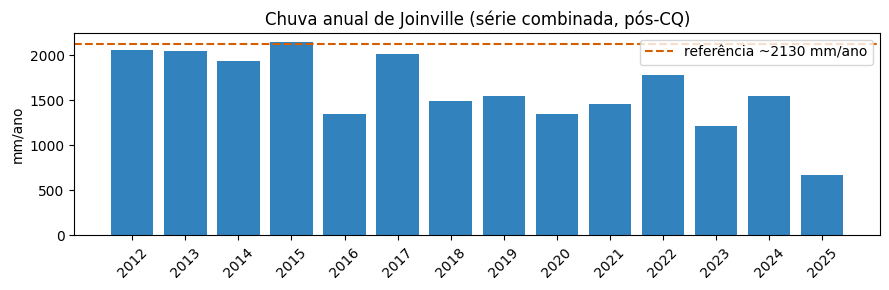

wettest recorded day (post-QC): {'date': '2012-06-05', 'mm': 115.9}


In [8]:
import matplotlib.pyplot as plt
ch = load_json(SITE/"city_history.json")
if ch:
    ann = [(a["year"], a["rain_total"]) for a in ch["annual"] if a.get("rain_total")]
    ys, mm = zip(*ann)
    fig, ax = plt.subplots(figsize=(9,3))
    ax.bar([str(y) for y in ys], mm, color="#3182bd")
    ax.axhline(ch["reference_annual_rain_mm"], color="#D55E00", ls="--", lw=1.5,
               label=f"referência ~{ch['reference_annual_rain_mm']} mm/ano")
    ax.set_ylabel("mm/ano"); ax.set_title("Chuva anual de Joinville (série combinada, pós-CQ)")
    ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
    print("wettest recorded day (post-QC):", ch["story"]["wettest_day"])
else:
    print("(city_history.json not found)")

## 6 · Stage D — WRF forecast (Previsão)

The CPTEC/INPE WRF (AMS **7 km**) is downloaded (`fetch_wrf.py`), then `build_wrf_basins.py`:

- **De-accumulates rain.** WRF rain is accumulated *from initialisation*, so the hourly rate is the
  difference between successive hours. Temperature and wind are **instantaneous** and are **never
  differenced** (temperature only K→°C; wind u,v → speed = √(u²+v²), meteorological
  direction = (270 − atan2(v,u)) mod 360). *Mixing these two conventions silently corrupts the data —
  it is the one rule that cannot be broken.*
- **Area-weights** each 7-km cell onto the 7 basins and 43 bairros: cells and polygons are projected to
  an **equal-area** CRS (SIRGAS 2000 / UTM 22S, EPSG:31982) and intersected exactly; a polygon's value
  is the area-weighted mean of the cells it covers. A *uniform field reproduces itself everywhere* —
  the invariant we test for correctness.
- **Times are local (UTC−3)**; the run cycle keeps its UTC label (00Z/12Z).

Two levels of output: the per-run files (**overwritten** each day) and the **cumulative archive**
(`archive_wrf_grid.py` → `wrf_grid_archive.csv`), which appends every run's native-resolution per-cell
hourly values so the model history is retrievable later.

In [9]:
wf = load_json(SITE/"wrf_forecast.json")
if wf:
    print("source     :", wf["source"])
    print("run (UTC)  :", wf["run_time"], "| steps:", wf["n_steps"], "| local grid:",
          len(wf["lat"]),"x",len(wf["lon"]))
    print("valid time :", wf["valid_times"][0], "…", wf["valid_times"][-1], f"({wf['tz']})")
    b = pd.DataFrame([{ "bacia":x["name"], "chuva_total_mm":x["rain"]["total_mm"],
                        "temp_media_C":x.get("temp",{}).get("mean"),
                        "vento_medio_ms":x.get("wind",{}).get("mean_ms")} for x in wf["basins"]])
    display(b.sort_values("chuva_total_mm", ascending=False))
else:
    print("(wrf_forecast.json not found)")

source     : CPTEC/INPE WRF AMS 7km
run (UTC)  : 2026-07-26 00:00:00 | steps: 9 | local grid: 10 x 10
valid time : 2026-07-26 04:00 … 2026-07-26 12:00 (America/Sao_Paulo (UTC-3))


,bacia,chuva_total_mm,temp_media_C,vento_medio_ms
1,Bacias independentes da vertente leste,0.11,15.9,1.42
2,Bacia Hidrográfica da vertente sul,0.08,15.8,1.10
3,Bacia Hidrográfica do Piraí,0.05,15.6,1.14
6,Bacia Hidrográfica do Rio Cachoeira,0.03,15.8,1.06
0,Bacia Hidrográfica do Palmital,0.01,16.2,2.10
5,Bacia Hidrográfica do Cubatão (sub-bacia),0.01,15.6,2.21
4,Bacia Hidrográfica do Itapocuzinho,0.00,15.8,1.56


In [10]:
# The cumulative archive: one growing long-format CSV, native 7-km cells, hourly, one row per run×time×cell.
arch = SITE/"wrf_grid_archive.csv"
if arch.exists():
    a = pd.read_csv(arch)
    print(f"archive rows: {len(a):,} | runs: {a.run_time.nunique()} | "
          f"valid times: {a.valid_time.nunique()} | cells: {a[['i','j']].drop_duplicates().shape[0]}")
    display(a.head(3))
else:
    print("(archive not built yet — created by archive_wrf_grid.py after the first WRF run)")

archive rows: 900 | runs: 1 | valid times: 9 | cells: 100


,run_time,valid_time,lead_h,i,j,lat,lon,rain_mm_h,temp_degC,u10_ms,v10_ms,wind_ms,wind_dir_deg
0,2026-07-26 00:00:00,2026-07-26 04:00,7,0,0,-26.6114,-49.234,0.0,14.2,0.7,-1.7,1.8,338
1,2026-07-26 00:00:00,2026-07-26 04:00,7,0,1,-26.6114,-49.164,0.0,13.9,0.6,-1.1,1.2,331
2,2026-07-26 00:00:00,2026-07-26 04:00,7,0,2,-26.6114,-49.094,0.0,13.5,0.7,-0.5,0.8,306


## 7 · Stage E — ENSO (El Niño / La Niña)

`build_enso.py` pulls the **NOAA/CPC Oceanic Niño Index (ONI)** and applies the official rule: an event
is ONI ≥ +0.5 °C (El Niño) or ≤ −0.5 °C (La Niña) sustained for **≥ 5 overlapping 3-month seasons**;
intensity is graded by |ONI| (weak 0.5–0.9, moderate 1.0–1.4, strong 1.5–1.9, very strong ≥ 2.0). The
Chuva–Rio daily plot shades these phases. In southern Brazil El Niño tends to wetter years and La Niña
to drier — the dashboard only *overlays* the phase; it does not infer causation.

In [11]:
enso = load_json(SITE/"enso.json")
if enso:
    ev = enso.get("events", enso)
    if isinstance(ev, list):
        ex = pd.DataFrame(ev).head(6)
        display(ex)
    print("rule:", enso.get("rule","(see build_enso.py)"))
else:
    print("(enso.json not found)")

rule: El Nino ONI>=+0.5 / La Nina ONI<=-0.5 for >=5 consecutive overlapping 3-month seasons (NOAA)


## 8 · Stage F — Publishing (fully automatic)

GitHub **Actions** run the scripts on a schedule and commit the small output files; GitHub **Pages**
serves `site/` for free. No server, no manual step.

| Workflow | When | What it does |
|---|---|---|
| `build.yml` | on data push + weekly | rebuild the observed-data pages |
| `update-data.yml` | weekly | ingest new drops → rain QC → refresh; also ENSO |
| `forecast-wrf.yml` | **daily** | fetch newest WRF → basins/bairros → **append to the grid archive** → commit |
| `sync-drive.yml` | weekly (optional) | pull new logger files from Drive |

The repository is **public**, so Actions minutes are **unlimited** (~270–300 Linux-min/month total).
The daily forecast commit uses `[skip ci]` and keeps the repo active (avoiding GitHub's 60-day
auto-disable of scheduled workflows).

### Reproduce it yourself
1. Clone the repo. 2. `pip install -r requirements.txt`. 3. Put the raw logger files where the manifest
expects them (or drop new ones in `data/incoming/`). 4. Run `python scripts/build_hourly_daily.py …`
(baseline) — **rain QC runs automatically at the end** — then the `build_*` scripts, or just let the
Actions do it. 5. Open `site/index.html`. Every number you see was produced by the code above, from the
files you can download, under the rules documented here.

## References

1. **USGS** — *How Streamflow is Measured* (stage / gage height above an arbitrary datum).
2. **Rousseeuw, P. J. & Croux, C. (1993)** — *Alternatives to the Median Absolute Deviation*, JASA 88(424):1273–1283. (MAD; constant 1.4826.)
3. **De Mello, Y. R. (2020)** — precipitation distribution & Serra do Mar orographic control, SC (~2,130 mm/yr, 42-gauge mean).
4. **Rodrigues, M. L. G. (2015)** — orographic rainfall events in Santa Catarina.
5. **NOAA/CPC** — Oceanic Niño Index (ONI): 3-month running Niño-3.4 SST anomaly; |ONI| ≥ 0.5 for ≥ 5 overlapping seasons.
6. **CPTEC/INPE** — WRF model, AMS 7 km domain.
7. **WRF Users' Guide** & **ECMWF** accumulated-variable conventions (de-accumulate rain; never difference instantaneous fields).
8. **WMO (2018)** — *Guide to Instruments and Methods of Observation* (WMO-No. 8): physical-plausibility / gross-error checks with **flagging** (not silent deletion).
9. **SIRGAS 2000 / UTM 22S (EPSG:31982)** — equal-area CRS for exact cell ∩ polygon weighting.
10. **IBGE** — municipal / state boundaries (via *tbrugz/geodata-br*).
11. **SEPROT** — Secretaria de Proteção Civil e Segurança Pública, Prefeitura de Joinville (primary data).

*Companion documents:* `README.md` (bundle guide), `METODOLOGIA_DADOS.md` (per-page methodology),
`logs/Joinville_dashboard_forecast_log.md` (decision log), `notebooks/joinville_meteo_consolidation.ipynb`
(ingestion detail), `notebooks/CPTEC_WRF_Joinville_downloader.ipynb` (WRF download).